In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import copy
import time

# Import PINN model and training functions from source
from src.model import PINN
from src.data import (
    generate_boundary_points,
    generate_initial_points,
    generate_collocation_points,
)
from src.train import train_pinn
from src.evaluate import relativeERROR

# Set default data type to float32
torch.set_default_dtype(torch.float)

# PyTorch random number generator
torch.manual_seed(1234)

**Heat equation with heat source**

$$\frac{\partial y}{\partial t} =\frac{\partial^2 y}{\partial x^2}$$

$$x\in[-1,1]$$
$$t\in[0,1]$$

### Initial Condition:

$$y(x,0)=sin(\pi x)$$

### Boundary Conditions:

$$y(-1,t)=0$$
$$y(1,t)=0$$

### Exact solution:

$$y(x,t)=e^{-\pi^2t}sin(\pi x)$$

In [3]:
# Generate data points
x_bc, y_bc = generate_boundary_points(100)
def heat_initial_function(x):
    return torch.sin(torch.pi*x)
x_ic, y_ic = generate_initial_points(100, heat_initial_function)
col_points = generate_collocation_points(1000)

In [4]:
def heat_equation_no_source(g, u, derivs):
    x, t = g[:, [0]], g[:, [1]]
    return derivs['u_t'] - derivs['u_xx']

def exact_solution_heat_no_source(x, t):
    return torch.exp(-torch.pi**2 * t) * torch.sin(torch.pi * x)

In [5]:
# Visualising PINN Prediction over 10000 epochs using heatmap, using LBFGS optimiser
# Create Grid Points
x = torch.linspace(-1,1,500)
t = torch.linspace(0,1,500)
X, T = torch.meshgrid(x,t, indexing='ij')
grid = torch.hstack((
    X.reshape(-1, 1),
    T.reshape(-1, 1)))

# Create untrained PINN's all using the same inital state
pinn = PINN()
final_loss, history = train_pinn(pinn,x_bc,y_bc, x_ic, y_ic, col_points, PDE_residual_fn = heat_equation_no_source, var_names = ['x', 't'], use_LBFGS= True, epochs = 10000)
with torch.no_grad():
    predicted_values = pinn(grid)

# Exact values using known PDE solution
exact_values = exact_solution_heat_no_source(grid[:,[0]], grid[:,[1]])

print(f"Relative error: {relativeERROR(predicted_values,exact_values).item():.6f}")

Relative error: 0.006185


/Users/willcowling/Library/Python/3.9/lib/python/site-packages/torch/optim/lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  loss = float(closure())


Text(0, 0.5, 't')

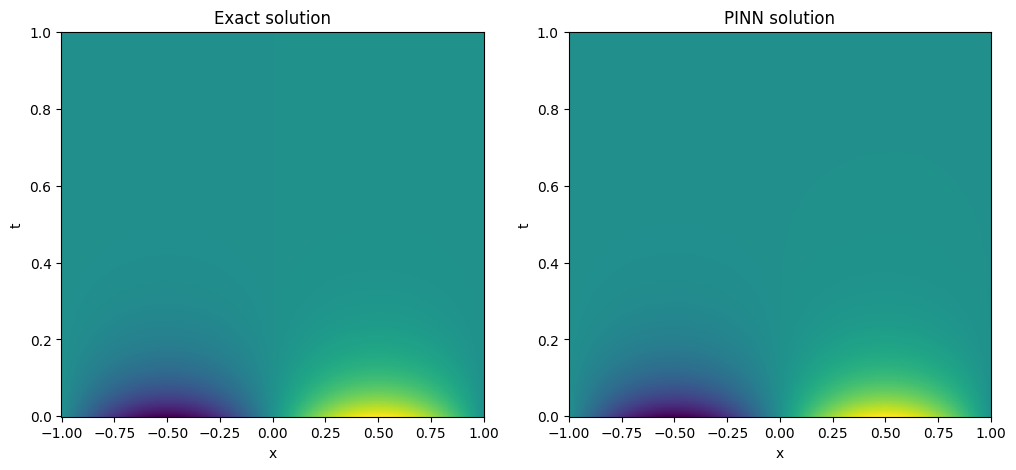

In [6]:
# Create Heatmap
fig, axs = plt.subplots(1,2, figsize = (12,5))
axs[0].pcolormesh(X,T,exact_values.reshape(X.shape))
axs[0].set_title('Exact solution')
axs[0].set_xlabel('x')
axs[0].set_ylabel('t')

axs[1].pcolormesh(X,T,predicted_values.reshape(X.shape))
axs[1].set_title('PINN solution')
axs[1].set_xlabel('x')
axs[1].set_ylabel('t')

Text(0, 0.5, 't')

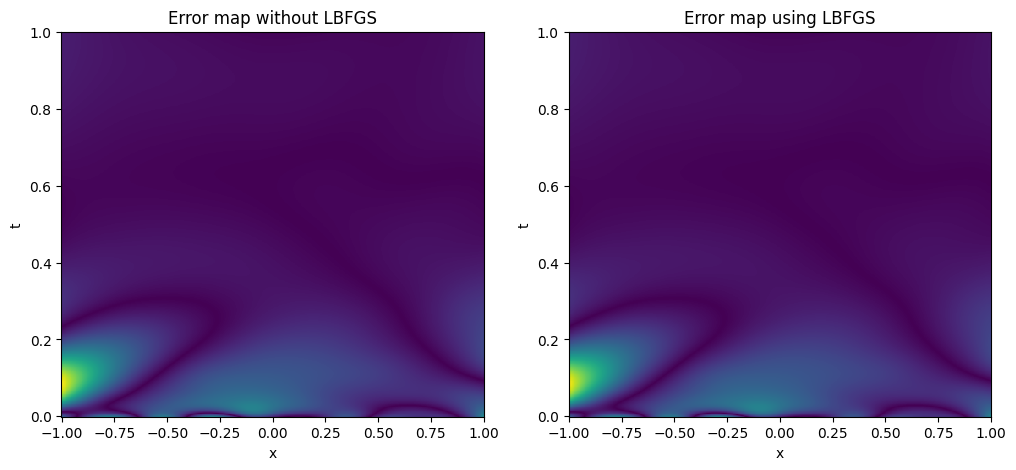

In [7]:
# Create Error Heatmap Comparing Relative Error with/without LBFGS
fig, axs = plt.subplots(1,2, figsize = (12,5))
axs[0].pcolormesh(X,T,np.abs(predicted_values-exact_values).reshape(X.shape))
axs[0].set_title('Error map without LBFGS')
axs[0].set_xlabel('x')
axs[0].set_ylabel('t')

axs[1].pcolormesh(X,T,np.abs(predicted_values-exact_values).reshape(X.shape))
axs[1].set_title('Error map using LBFGS')
axs[1].set_xlabel('x')
axs[1].set_ylabel('t')

Testing Causal Training. Our relative error is higher for the no_source heat equation. This is most likely due PINN struggling to keep up with the faster exponential decay. Causal training weights the PDE loss so that later time-regions are only "allowed" to contribute once earlier time-regions have converged. I have implemented this here by 'bucketing' collocation points by time and scaling each bucket's loss by exp(-eps*cumulative loss of earlier buckets). Credit to Wang et al., "Respecting Causality for Training Physics-Informed Neural Networks".

In [ ]:
# Import PINN model and training functions from source
from src.model_causal import PINN
from src.data import (
    generate_boundary_points,
    generate_initial_points,
    generate_collocation_points)
from src.train_causal import train_pinn_causal

In [9]:
# Create PINN and train
pinn = PINN()
initial_pinn_state = copy.deepcopy(pinn.state_dict())

# Training over just one data bucket (normal training)
pinn_normal = PINN()
pinn_normal.load_state_dict(initial_pinn_state)
train_pinn(pinn_normal,x_bc,y_bc, x_ic, y_ic, col_points, PDE_residual_fn=heat_equation_no_source, var_names = ['x', 't'], epochs = 10000, 
    eps=1e-5, n_buckets = 1)
with torch.no_grad():
    predicted_values_normal = pinn_normal(grid)

# Using 10 data buckets
pinn_causal = PINN()
pinn_causal.load_state_dict(initial_pinn_state)
train_pinn(pinn_causal,x_bc,y_bc, x_ic, y_ic, col_points, PDE_residual_fn = heat_equation_no_source, var_names = ['x', 't'], epochs = 10000, 
    eps=1e-5, n_buckets = 10)
with torch.no_grad():
    predicted_values_causal = pinn_causal(grid)


# Exact values using known PDE solution
exact_values = exact_solution_heat_no_source(grid[:,[0]], grid[:,[1]])

print(f"Relative error (normal training): {relativeERROR(predicted_values_normal,exact_values).item():.6f}")
print(f"Relative error (causal training): {relativeERROR(predicted_values_causal,exact_values).item():.6f}")

Relative error (normal training): 0.006222
Relative error (causal training): 0.007180


Text(0, 0.5, 'Relative error')

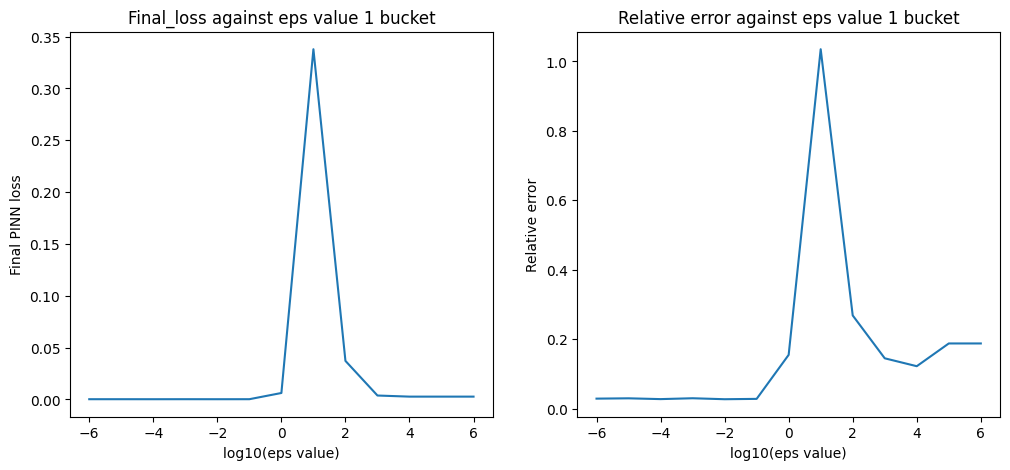

In [10]:
# Deducing the optimum value of eps
final_loss_array = []
relative_error_array = []
pinn = PINN()
initial_pinn_state = copy.deepcopy(pinn.state_dict())

# Exact solution to test against
exact_values = exact_solution_heat_no_source(grid[:,[0]], grid[:,[1]])

# Train for different numbers of collocation points
eps_values = [1e-6, 1e-5,1e-4,1e-3,1e-2,1e-1, 1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]
for i in eps_values:
     pinn = PINN()
     pinn.load_state_dict(initial_pinn_state)
     history, final_loss = train_pinn(pinn,x_bc,y_bc, x_ic,y_ic,col_points, PDE_residual_fn=heat_equation_no_source, var_names = ['x', 't'], eps = i, n_buckets=10)
     final_loss_array.append(final_loss.item())
     with torch.no_grad():
          predicted_values_LBFGS = pinn(grid)
     relative_error_array.append(relativeERROR(predicted_values_LBFGS,exact_values).item())

# Plotting
fig, axs = plt.subplots(1,2, figsize = (12,5))
axs[0].plot(np.log10(eps_values),final_loss_array)
axs[0].set_title('Final_loss against eps value 1 bucket')
axs[0].set_xlabel('log10(eps value)')
axs[0].set_ylabel('Final PINN loss')
axs[1].plot(np.log10(eps_values),relative_error_array)
axs[1].set_title('Relative error against eps value 1 bucket')
axs[1].set_xlabel('log10(eps value)')
axs[1].set_ylabel('Relative error')

It is clear that causal training has not been as successful as imagined. This is likely because the heat equation is a well-behaved PDE. Causal training is mostly used on stiff systems where early errors compound significantly. Therefore, it is probably best to test causal training properly on another equation. 